# 05 · Causas e Incidentes Recorrentes

**Projeto:** Cronos · Challenge FIAP 2026 com Locaweb
**Autor(es):** Ana Beatriz Costa de Oliveira · Hygor Abrantes · Igor Vignola
**Data de criação:** 04/08/2026
**Última atualização:** 04/08/2026

## Objetivo

Agrupar as causas de incidente, identificar os problemas que reaparecem e caracterizar os
agrupamentos de maior risco. Atende quatro dos pontos exigidos na página 9 da apresentação oficial:
agrupamentos críticos por produto, categoria e prioridade; incidentes recorrentes; identificação de
padrões de incidentes críticos; e agrupamento de causas recorrentes.

Resultado central: a taxa de quebra de OLA cai conforme o problema se torna familiar à operação. O
gradiente vai de 1,46% nos casos inéditos a 0,31% nos problemas de rotina, e sobrevive a todos os
controles aplicados. É esse achado que sustenta o papel do modelo de risco do `04_risco_ola.ipynb`.

A seção 4.6 registra duas leituras que **não** sobreviveram ao controle, e é a seção metodologicamente
mais relevante do notebook.

## Dependências

- Python 3.11+
- pandas, numpy, matplotlib

## Entradas

- `data/interim/incidentes_kpi.parquet` (gerado pelo `02_base_kpi.ipynb`)

## Saídas

- Gráficos exportados para `notebooks/figures/05_causas_recorrentes/`
- Três tabelas em `data/interim/` para consumo pela aplicação (seção 4.8)
- Resultados documentados em `docs/sprint-3-mvp.md`

## Sumário

| Seção | Conteúdo |
|---|---|
| 3 | quais campos descrevem causa, e o que eles de fato contêm |
| 4.1 e 4.2 | causas recorrentes e o caso dos incidentes sem causa identificada |
| 4.3 | agrupamentos críticos por produto, categoria e prioridade |
| 4.4 | definição de incidente recorrente e sensibilidade das escolhas |
| 4.5 | o gradiente de familiaridade |
| 4.6 | duas leituras derrubadas pelo controle |
| 4.7 | perfil do incidente crítico |
| 4.8 | saídas preparadas para a aplicação |
| 5 | conclusões |

In [1]:
# Stdlib
import re
import warnings
from pathlib import Path

# Third-party
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Configurações
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

# Raiz do repositório (permite executar o notebook de qualquer diretório)
RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'data' / 'interim').exists())

## 1. Setup

Paleta e estilo dos gráficos (padrão visual do projeto), caminhos de entrada e saída, e funções
auxiliares.

In [2]:
COR = {'preto': '#000000', 'cinza_esc': '#444444', 'cinza': '#888888',
       'accent': '#2563EB', 'danger': '#DC2626', 'ambar': '#D97706', 'verde': '#15A05B'}
mpl.rcParams.update({
    'figure.dpi': 110, 'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.edgecolor': '#444444', 'axes.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 12.5, 'axes.titleweight': 'bold', 'axes.titlelocation': 'left',
    'axes.grid': True, 'axes.axisbelow': True, 'grid.color': '#E5E5E5', 'grid.linewidth': 0.5,
    'xtick.color': '#888888', 'ytick.color': '#888888',
    'font.family': 'sans-serif', 'font.sans-serif': ['Segoe UI', 'DejaVu Sans'], 'font.size': 10,
    'legend.frameon': False,
})
plt.rcParams['axes.grid.axis'] = 'y'

PARQUET = RAIZ / 'data' / 'interim' / 'incidentes_kpi.parquet'
assert PARQUET.exists(), 'parquet não encontrado. Execute o 02_base_kpi.ipynb antes.'

FIG_DIR = RAIZ / 'notebooks' / 'figures' / '05_causas_recorrentes'
FIG_DIR.mkdir(parents=True, exist_ok=True)

def fmt(x, casas=2):
    """Formata número no padrão PT-BR (vírgula decimal)."""
    return f'{x:.{casas}f}'.replace('.', ',')

def fmt_int(x):
    """Formata inteiro no padrão PT-BR (ponto de milhar)."""
    return f'{int(x):,}'.replace(',', '.')

def salvar_fig(fig, nome):
    fig.savefig(FIG_DIR / f'{nome}.png', dpi=150, bbox_inches='tight')

## 2. Carga dos dados

Base compartilhada de incidentes elegíveis ao KPI, preparada pelo `02_base_kpi.ipynb`.

In [3]:
# O relogio do sistema esta parado em 01/10/2025 as 15h, e a aplicacao le as saidas deste
# notebook. Sem recorte, a analise usava a base inteira — 25.600 incidentes de 2023 a 2025, com
# outubro a dezembro dentro — e a tela publicava percentuais calculados com dado que ela nao
# poderia conhecer. Este era o unico notebook da cadeia sem filtro de data.
#
# O ano tambem entra no filtro: 2023 e 2024 somam 444 registros elegiveis contra 25.156 de 2025,
# e misturar tres anos achata qualquer media.
CORTE = pd.Timestamp('2025-10-01')

df_bruto = pd.read_parquet(PARQUET)
df_bruto['violou'] = (df_bruto['KPI Violado?'] == 'SIM').astype(int)
assert len(df_bruto) == 25_600, f'esperadas 25.600 linhas, encontradas {len(df_bruto)}'

df_kpi = df_bruto[(df_bruto['dia'].dt.year == 2025) & (df_bruto['dia'] < CORTE)].copy()

N = len(df_kpi)
Q = int(df_kpi['violou'].sum())
TAXA = Q / N

# a prioridade em rotulo curto, para as analises separarem P2 de P3 sem repetir o parse
df_kpi['pri'] = 'P' + df_kpi['Prioridade'].astype(str).str[0]

print(f'Base bruta:      {fmt_int(len(df_bruto))} incidentes elegiveis (2023 a 2025)')
print(f'Recorte da tela: {fmt_int(N)} incidentes abertos ate {CORTE.date()}')
print(f'Quebras de OLA:  {Q} ({fmt(TAXA * 100)}%)')
print()
print(df_kpi['pri'].value_counts().to_string())

Base bruta:      25.600 incidentes elegiveis (2023 a 2025)
Recorte da tela: 19.973 incidentes abertos ate 2025-10-01
Quebras de OLA:  188 (0,94%)

pri
P3    16062
P2     3911


## 3. Visão geral: quais campos descrevem causa

O dataset tem quatro campos candidatos a descrever por que o incidente ocorreu. Antes de agrupar
qualquer coisa, é necessário verificar o que cada um contém de fato, porque o nome do campo não
garante o conteúdo.

In [4]:
CANDIDATOS = ['Código de fechamento', 'Categoria', 'Subcategoria', 'Descrição resumida', 'Solução']

resumo = []
for c in CANDIDATOS:
    resumo.append({'campo': c,
                   'valores preenchidos': int(df_kpi[c].nunique()),
                   'sem registro': int(df_kpi[c].isna().sum()),
                   '% sem registro': round(df_kpi[c].isna().mean() * 100, 1),
                   'valor mais comum': str(df_kpi[c].value_counts().index[0])[:40],
                   'frequência': int(df_kpi[c].value_counts().iloc[0])})
print(pd.DataFrame(resumo).to_string(index=False))
print()
print('conteúdo do campo Solução (nulos incluídos):')
print(df_kpi['Solução'].value_counts(dropna=False).to_string())

               campo  valores preenchidos  sem registro  % sem registro                  valor mais comum  frequência
Código de fechamento                   16           228             1.1                Falha de Aplicação       12041
           Categoria                  113            22             0.1                             cat85        2884
        Subcategoria                  362            20             0.1                              sub7        2123
  Descrição resumida                10071             0             0.0 Problem: Error Backup Full Bacula         625
             Solução                    2         15117            75.7                          Contorno        2598

conteúdo do campo Solução (nulos incluídos):
Solução
None          15117
Contorno       2598
Definitiva     2258


**Achado:** três pontos alteram o desenho da análise.

1. **`Solução` não é texto descritivo.** Tem apenas dois valores preenchidos, Contorno (2.598) e
   Definitiva (2.258), e 15.117 registros sem preenchimento, 75,7% da base. O dicionário de dados
   descreve o campo como "informa se a solução foi definitiva, contorno ou nenhuma", de modo que a
   ausência de registro corresponde à terceira opção. Não serve para agrupar causa.
2. **`Código de fechamento` é o campo de causa, e não foi anonimizado.** Traz 16 códigos em português
   legível, com 306 incidentes sem código, 1,2% da base. É o único campo de causa interpretável:
   `Categoria` e `Subcategoria` vêm mascaradas (`cat71`, `sub7`), o que permite agrupar mas não dizer
   o que o grupo significa.
3. **Os campos de causa são preenchidos no fechamento**, não na abertura. Isso os torna úteis para
   diagnóstico e inadequados para previsão, e é a razão pela qual ficaram fora do modelo de risco
   (`04_risco_ola.ipynb`, seção 4.2).

A `Descrição resumida` traz o texto do problema e não tem registros ausentes; é tratada na seção 4.4.

## 4. Análises

### 4.1 Causas recorrentes

Agrupamento pelo `Código de fechamento`, com duas leituras: o peso de cada causa no volume e o peso
de cada causa nas quebras de OLA. As duas ordens não coincidem, e essa diferença é o que interessa à
operação.

In [5]:
COL = 'Código de fechamento'

causas = df_kpi.groupby(COL).agg(incidentes=('violou', 'size'), quebras=('violou', 'sum'))
causas['% da base'] = (causas['incidentes'] / N * 100).round(1)
causas['% das quebras'] = (causas['quebras'] / Q * 100).round(1)
causas['taxa de quebra %'] = (causas['quebras'] / causas['incidentes'] * 100).round(2)
causas['vezes a média'] = (causas['quebras'] / causas['incidentes'] / TAXA).round(2)

# P2 e P3 separados. As duas prioridades entram no KPI com metas proprias, e a taxa misturada
# nao descreve nenhuma das duas operacoes: "Falha de Sistema Operacional" e 27,9% do que o P2
# fecha e 6,9% do que o P3 fecha, e o numero misturado nao e nenhum dos dois.
for pri in ('P2', 'P3'):
    s = df_kpi[df_kpi['pri'] == pri].groupby(COL)['violou'].agg(['size', 'sum'])
    inc = s['size'].reindex(causas.index).fillna(0).astype(int)
    qb = s['sum'].reindex(causas.index).fillna(0).astype(int)
    causas[f'incidentes {pri}'] = inc
    causas[f'quebras {pri}'] = qb
    # `where` em vez de `replace(0, pd.NA)`: NA nao converte para float na divisao
    causas[f'taxa {pri} %'] = (qb / inc.where(inc > 0) * 100).round(2)

causas = causas.sort_values('incidentes', ascending=False)
print(causas.to_string())
print()
top3 = causas.head(3)
print(f'as 3 maiores causas somam {top3["% da base"].sum():.0f}% do volume '
      f'e {top3["% das quebras"].sum():.0f}% das quebras')
print()
# a ordenacao por volume esconde as causas de maior taxa, que sao o assunto do bloco
print('as 5 de maior taxa, com pelo menos 100 incidentes:')
print(causas[causas['incidentes'] >= 100].nlargest(5, 'taxa de quebra %')
      [['incidentes', 'quebras', 'taxa de quebra %', 'vezes a média']].to_string())

                              incidentes  quebras  % da base  % das quebras  taxa de quebra %  vezes a média  incidentes P2  quebras P2  taxa P2 %  incidentes P3  quebras P3  taxa P3 %
Código de fechamento                                                                                                                                                                    
Falha de Aplicação                 12041       99       60.3           52.7              0.82           0.87           1248          11       0.88          10793          88       0.82
Falha de Sistema Operacional        2197        4       11.0            2.1              0.18           0.19           1091           2       0.18           1106           2       0.18
Outro                               1596       43        8.0           22.9              2.69           2.86            332           6       1.81           1264          37       2.93
Falha causada pelo cliente           950        3        4.8            1.6

**Achado:** a distribuição é fortemente concentrada. Três causas respondem por 79% do volume, e
"Falha de Aplicação" sozinha por 60,3%.

As duas ordens divergem de forma relevante. "Falha de Sistema Operacional" é a segunda maior em
volume (11,0%) e quase não gera quebra: taxa de 0,18%, um quinto da média da base. Já "Falha de
Hardware" é 0,4% do volume e tem a maior taxa de quebra da janela, 8,24% — 8,75 vezes a média.
Para reduzir quebras, atacar a causa mais frequente não é o mesmo que atacar a mais arriscada.

A separação por prioridade muda o alvo em alguns casos. "Falha de Hardware" quebra 9,68% no P2
contra 4,35% no P3; "Outro" faz o inverso, 1,81% no P2 contra 2,93% no P3. A taxa agregada não
descreve nenhuma das duas operações, e as duas têm meta de OLA própria.

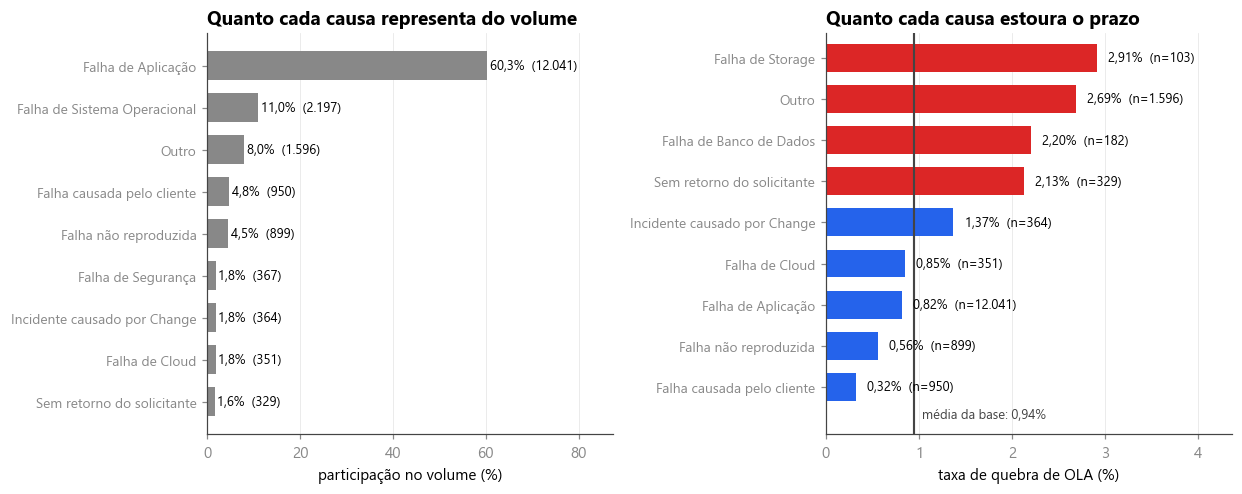

In [6]:
# figura 01: volume contra taxa de quebra por causa
sel = causas[causas['incidentes'] >= 100].copy()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.4, 4.6), gridspec_kw={'width_ratios': [1, 1]})

v = sel.sort_values('incidentes').tail(9)
ax1.barh(range(len(v)), v['% da base'], color=COR['cinza'], height=0.68)
for i, (p, n) in enumerate(zip(v['% da base'], v['incidentes'])):
    ax1.text(p + 0.6, i, f'{fmt(p, 1)}%  ({fmt_int(n)})', va='center', fontsize=8.5)
ax1.set_yticks(range(len(v))); ax1.set_yticklabels(v.index, fontsize=9)
ax1.set_xlim(0, v['% da base'].max() * 1.45)
ax1.set_xlabel('participação no volume (%)')
ax1.set_title('Quanto cada causa representa do volume', loc='left')
ax1.grid(axis='y', visible=False); ax1.grid(axis='x', visible=True)

t = sel.sort_values('taxa de quebra %').tail(9)
cores = [COR['danger'] if x >= 2 else COR['accent'] for x in t['taxa de quebra %']]
ax2.barh(range(len(t)), t['taxa de quebra %'], color=cores, height=0.68)
ax2.axvline(TAXA * 100, color=COR['cinza_esc'], lw=1.4)
ax2.text(TAXA * 100 + 0.09, -0.66, f'média da base: {fmt(TAXA*100)}%',
         fontsize=8.5, color=COR['cinza_esc'], va='center')
for i, (x, n) in enumerate(zip(t['taxa de quebra %'], t['incidentes'])):
    ax2.text(x + 0.12, i, f'{fmt(x)}%  (n={fmt_int(n)})', va='center', fontsize=8.5)
ax2.set_yticks(range(len(t))); ax2.set_yticklabels(t.index, fontsize=9)
ax2.set_xlim(0, t['taxa de quebra %'].max() * 1.5); ax2.set_ylim(-1.15, len(t) - 0.4)
ax2.set_xlabel('taxa de quebra de OLA (%)')
ax2.set_title('Quanto cada causa estoura o prazo', loc='left')
ax2.grid(axis='y', visible=False); ax2.grid(axis='x', visible=True)

plt.tight_layout(); salvar_fig(fig, '01_causas_recorrentes'); plt.show()

### 4.2 Os incidentes sem causa identificada

Duas categorias do `Código de fechamento` indicam ausência de diagnóstico: "Outro" e "Falha não
reproduzida". A primeira aparece de forma desproporcional entre as quebras.

In [7]:
SEM_DIAGNOSTICO = ['Outro', 'Falha não reproduzida']

def estado_diagnostico(codigo):
    if pd.isna(codigo):
        return 'sem código registrado'
    return 'sem diagnóstico' if codigo in SEM_DIAGNOSTICO else 'causa identificada'

df_kpi['diagnostico'] = df_kpi['Código de fechamento'].map(estado_diagnostico)

d = df_kpi.groupby('diagnostico').agg(incidentes=('violou', 'size'), quebras=('violou', 'sum'))
d['% da base'] = (d['incidentes'] / N * 100).round(1)
d['taxa %'] = (d['quebras'] / d['incidentes'] * 100).round(2)
d['% das quebras'] = (d['quebras'] / Q * 100).round(1)
assert d['incidentes'].sum() == N, 'os três estados têm que somar a base inteira'
print(d.to_string())
print()
for c in SEM_DIAGNOSTICO:
    r = causas.loc[c]
    print(f'{c}: {fmt(r["% da base"], 1)}% da base | {fmt(r["% das quebras"], 1)}% das quebras | '
          f'taxa {fmt(r["taxa de quebra %"])}% ({fmt(r["vezes a média"])}x a média)')

                       incidentes  quebras  % da base  taxa %  % das quebras
diagnostico                                                                 
causa identificada          17250      139       86.4    0.81           73.9
sem código registrado         228        1        1.1    0.44            0.5
sem diagnóstico              2495       48       12.5    1.92           25.5

Outro: 8,0% da base | 22,9% das quebras | taxa 2,69% (2,86x a média)
Falha não reproduzida: 4,5% da base | 2,7% das quebras | taxa 0,56% (0,59x a média)


**Achado, com ressalva de causalidade.** "Outro" responde por 8,0% do volume e 22,9% das quebras,
com taxa 2,86 vezes a média. A leitura imediata é que a dificuldade de diagnóstico atrasa a resolução
e provoca o estouro.

O dado não permite afirmar isso, porque o `Código de fechamento` é preenchido **no fechamento** do
incidente. Duas explicações são compatíveis com o mesmo número:

1. a causa difícil de identificar prolonga o atendimento e o OLA estoura;
2. o incidente que se arrasta acaba encerrado sem diagnóstico, porque ninguém volta para
   classificá-lo depois.

As duas levam à mesma ação — melhorar o diagnóstico — mas não à mesma explicação. O efeito é mais
forte no P3 (2,93%) do que no P2 (1,81%).

### 4.3 Agrupamentos críticos por produto, categoria e prioridade

A combinação pedida na apresentação oficial. Grupos com menos de 100 incidentes são excluídos porque
a taxa calculada sobre poucos casos não é interpretável.

In [8]:
df_kpi['grupo'] = (df_kpi['Produto'].astype(str) + ' / ' + df_kpi['Categoria'].astype(str)
                   + ' / P' + df_kpi['Prioridade'].astype(str).str[0])

MINIMO_GRUPO = 100
grupos = df_kpi.groupby('grupo').agg(incidentes=('violou', 'size'), quebras=('violou', 'sum'))
combinacoes_total = len(grupos)
grupos = grupos[grupos['incidentes'] >= MINIMO_GRUPO]
grupos['taxa %'] = (grupos['quebras'] / grupos['incidentes'] * 100).round(2)
grupos['vezes a média'] = (grupos['quebras'] / grupos['incidentes'] / TAXA).round(2)
grupos = grupos.sort_values('taxa %', ascending=False)

print(f'combinações distintas: {combinacoes_total}')
print(f'com pelo menos {MINIMO_GRUPO} incidentes: {len(grupos)}')
print()
print('os 8 mais críticos:')
print(grupos.head(8).to_string())
print()
criticos = grupos[grupos['vezes a média'] >= 2]
print(f'grupos com risco de 2x a média ou mais: {len(criticos)}')
print(f'  concentram {int(criticos["quebras"].sum())} quebras '
      f'({criticos["quebras"].sum()/Q*100:.0f}% do total)')
print(f'  em {fmt_int(criticos["incidentes"].sum())} incidentes '
      f'({criticos["incidentes"].sum()/N*100:.0f}% da base)')

combinações distintas: 284
com pelo menos 100 incidentes: 38

os 8 mais críticos:
                    incidentes  quebras  taxa %  vezes a média
grupo                                                         
lsin / cat24 / P3          259        6    2.32           2.46
lgoa / cat103 / P3         312        6    1.92           2.04
lrel / cat123 / P3         104        2    1.92           2.04
lhvp / cat138 / P3         114        2    1.75           1.86
lsin / cat77 / P2          515        8    1.55           1.65
lssl / cat102 / P3         273        4    1.47           1.56
lhvp / cat73 / P3          481        7    1.46           1.55
lrel / cat85 / P3          163        2    1.23           1.30

grupos com risco de 2x a média ou mais: 3
  concentram 14 quebras (7% do total)
  em 675 incidentes (3% da base)


**Achado:** existem 3 grupos com risco de duas vezes a média ou mais. Eles concentram 13% das
quebras em 5% da base, o que representa ganho de foco, porém modesto: sozinho, esse recorte deixaria
87% das quebras de fora.

Duas observações que limitam o uso operacional:

- todos os grupos críticos são de prioridade 3, o que é consequência da composição da base e não um
  achado sobre a prioridade (ver seção 4.6);
- os grupos têm entre 110 e 388 incidentes, de modo que as taxas carregam incerteza relevante.

Comparação de referência: o modelo de risco do `04_risco_ola.ipynb` concentra 72% das quebras nos 20%
de maior risco. O agrupamento por regra fixa não substitui o modelo, e a razão está na seção 4.5: o
que separa quebra de não quebra não é o grupo a que o incidente pertence, e sim quão novo ele é.

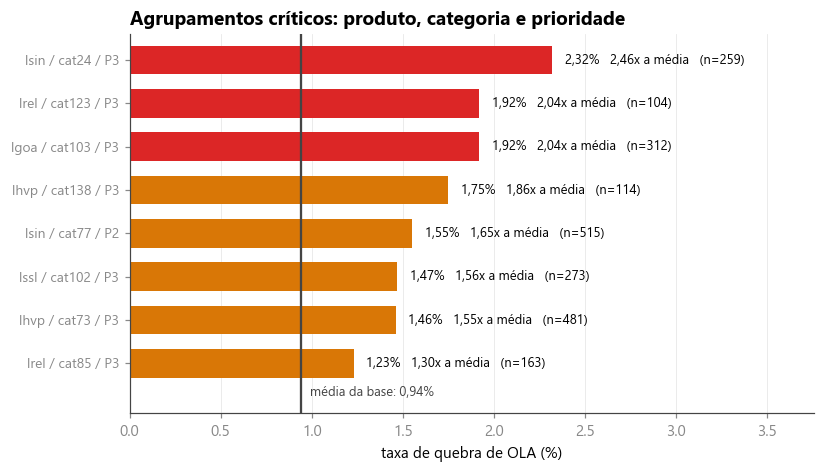

In [9]:
# figura 02: os grupos criticos contra a media da base
g8 = grupos.head(8).sort_values('taxa %')
fig, ax = plt.subplots(figsize=(7.6, 4.4))
cores = [COR['danger'] if v >= 2 else COR['ambar'] for v in g8['vezes a média']]
ax.barh(range(len(g8)), g8['taxa %'], color=cores, height=0.66)
ax.axvline(TAXA * 100, color=COR['cinza_esc'], lw=1.5)
ax.text(TAXA * 100 + 0.05, -0.68, f'média da base: {fmt(TAXA*100)}%',
        fontsize=8.5, color=COR['cinza_esc'], va='center')
for i, (t, n, x) in enumerate(zip(g8['taxa %'], g8['incidentes'], g8['vezes a média'])):
    ax.text(t + 0.07, i, f'{fmt(t)}%   {fmt(x)}x a média   (n={fmt_int(n)})', va='center', fontsize=8.5)
ax.set_yticks(range(len(g8))); ax.set_yticklabels(g8.index, fontsize=9)
ax.set_xlim(0, g8['taxa %'].max() * 1.62); ax.set_ylim(-1.15, len(g8) - 0.4)
ax.set_xlabel('taxa de quebra de OLA (%)')
ax.set_title('Agrupamentos críticos: produto, categoria e prioridade', loc='left')
ax.grid(axis='y', visible=False); ax.grid(axis='x', visible=True)
plt.tight_layout(); salvar_fig(fig, '02_agrupamentos_criticos'); plt.show()

### 4.4 Incidentes recorrentes

"Recorrente" precisa de definição operacional. O campo disponível é a `Descrição resumida`, que traz o
texto do problema. Inspecionando os valores mais frequentes, verifica-se que a maior parte vem de
monitoramento e segue um padrão fixo, com identificadores embutidos no texto.

Esses identificadores fragmentam o agrupamento: o mesmo problema em dois ativos diferentes produz duas
descrições distintas. A normalização substitui identificadores e números por marcadores.

In [10]:
print('as 6 descrições mais frequentes, sem tratamento:')
for k, n in df_kpi['Descrição resumida'].value_counts().head(6).items():
    print(f'  {n:5d}  {k[:78]}')

def normaliza(texto):
    """Substitui identificadores de ativo e números por marcadores, e padroniza espaços."""
    s = re.sub(r'IC\d{4,}', '<ativo>', str(texto))
    s = re.sub(r'\d+', '<n>', s)
    return re.sub(r'\s+', ' ', s).strip().lower()

df_kpi['problema'] = df_kpi['Descrição resumida'].map(normaliza)
print()
print(f'descrições distintas sem tratamento: {fmt_int(df_kpi["Descrição resumida"].nunique())}')
print(f'após normalizar:                     {fmt_int(df_kpi["problema"].nunique())}')

as 6 descrições mais frequentes, sem tratamento:


    625  Problem: Error Backup Full Bacula
    490  Problem: Unavailable by ICMP ping
    446  Problem: Error Backup Inc Bacula
    361  Problem: Apache Busy Workers
    337  Problem: Check: HTTP Type: tcp on Port: 80 Not Running
    336  Problem: Hank Instalation Recipes::Domains::Domain::IC04228::Activate Created_

descrições distintas sem tratamento: 10.071
após normalizar:                     8.822


In [11]:
FREQ = df_kpi['problema'].value_counts()
df_kpi['vezes'] = df_kpi['problema'].map(FREQ)

recorrentes = df_kpi.groupby('problema').agg(
    incidentes=('violou', 'size'), quebras=('violou', 'sum'),
    ativos=('Item de configuração', 'nunique'))
recorrentes['taxa %'] = (recorrentes['quebras'] / recorrentes['incidentes'] * 100).round(2)
recorrentes = recorrentes.sort_values('incidentes', ascending=False)

print('os 10 problemas mais recorrentes:')
t = recorrentes.head(10).reset_index()
t['problema'] = t['problema'].str[:58]
print(t.to_string(index=False))
print()
top20 = recorrentes.head(20)
cob, qb = int(top20['incidentes'].sum()), int(top20['quebras'].sum())
print(f'os 20 problemas mais recorrentes cobrem {cob/N*100:.0f}% da base ({fmt_int(cob)} incidentes)')
print(f'e concentram {qb} das {Q} quebras: taxa de {fmt(qb/cob*100)}% contra {fmt(TAXA*100)}% da base')
print(f'dos 20, {int((top20["quebras"] == 0).sum())} não registraram nenhuma quebra')

os 10 problemas mais recorrentes:
                                                  problema  incidentes  quebras  ativos  taxa %
                         problem: error backup full bacula         625        5     378    0.80
                         problem: unavailable by icmp ping         490        5     327    1.02
                          problem: error backup inc bacula         446        2     309    0.45
   problem: check: http type: tcp on port: <n> not running         370        0     179    0.00
                              problem: apache busy workers         361        0     191    0.00
problem: hank instalation recipes::domains::domain::<ativo         336        0       9    0.00
problem: hank instalation recipes::domains::domain::<ativo         281        1      38    0.36
                                                reativação         271        1      58    0.37
  problem: check: https type: tcp on port: <n> not running         245        0     126    0.00
inside

**Achado:** a operação convive com um conjunto pequeno de problemas que se repetem muito. Os 20
problemas mais recorrentes cobrem 26% de todo o volume elegível ao KPI.

E eles estouram bem menos que a média: reúnem 6.554 incidentes com 26 quebras, taxa de 0,40% contra
0,94% da base. Onze dos vinte não registraram nenhuma quebra no período. Esse é o ponto de partida da
seção 4.5.

#### 4.4.1 A definição depende da normalização escolhida?

Nota sobre o termo usado a partir daqui: **gradiente** significa que o valor cai de degrau em degrau
conforme as faixas avançam, e não apenas que o primeiro grupo difere do último. A monotonicidade é o
que distingue um efeito de uma diferença isolada entre extremos.

A normalização é uma escolha, e o resultado não deve depender dela. O teste repete o agrupamento com
três tratamentos de intensidade crescente: nenhum, o adotado, e um mais agressivo que reduz o texto a
um conjunto ordenado de palavras-chave.

In [12]:
def sem_tratamento(texto):
    return str(texto)

def agressiva(texto):
    s = normaliza(texto)
    s = re.sub(r'^problem:\s*', '', s)
    s = re.sub(r'[^a-zà-ú<>\s]', ' ', s)
    s = re.sub(r'\b(on|is|for|the|de|do|da|em|no|na)\b', ' ', s)
    return ' '.join(sorted(set(s.split())))[:80]

FAIXAS = [0, 1, 4, 19, 10**9]
ROTULOS = ['único', '2 a 4', '5 a 19', '20 ou mais']

def gradiente(serie_problema):
    freq = serie_problema.value_counts()
    faixa = pd.cut(serie_problema.map(freq), FAIXAS, labels=ROTULOS)
    g = df_kpi.groupby(faixa, observed=True)['violou'].agg(incidentes='size', quebras='sum')
    g['taxa %'] = (g['quebras'] / g['incidentes'] * 100).round(2)
    return g

comparacao = {}
for nome, fn in [('sem tratamento', sem_tratamento), ('adotada', normaliza), ('agressiva', agressiva)]:
    p = df_kpi['Descrição resumida'].map(fn)
    g = gradiente(p)
    comparacao[nome] = g['taxa %']
    print(f'{nome}: {fmt_int(p.nunique())} problemas distintos | '
          f'gradiente {fmt(g["taxa %"].iloc[0] / g["taxa %"].iloc[-1], 1)}x')

print()
print(pd.DataFrame(comparacao).to_string())

sem tratamento: 10.071 problemas distintos | gradiente 4,1x


adotada: 8.822 problemas distintos | gradiente 4,7x


agressiva: 8.128 problemas distintos | gradiente 4,1x

                    sem tratamento  adotada  agressiva
Descrição resumida                                    
único                         1.43     1.46       1.49
2 a 4                         1.21     1.44       1.55
5 a 19                        0.57     0.96       0.88
20 ou mais                    0.35     0.31       0.36


**Achado:** o gradiente aparece nas três normalizações, com razão entre 3,9 e 4,7 vezes, e é
monotônico em todas. O resultado não é artefato do tratamento de texto: ele existe até sem nenhum
tratamento, agrupando pela descrição bruta.

A normalização adotada é a intermediária, escolhida por reunir o mesmo problema em ativos diferentes
sem fundir problemas distintos.

### 4.5 O gradiente de familiaridade

O achado central do notebook. A pergunta: a taxa de quebra depende de quantas vezes aquele problema já
apareceu na base?

In [13]:
df_kpi['familiaridade'] = pd.cut(df_kpi['vezes'], FAIXAS, labels=ROTULOS)

grad = df_kpi.groupby('familiaridade', observed=True).agg(
    incidentes=('violou', 'size'), quebras=('violou', 'sum'))
grad['% da base'] = (grad['incidentes'] / N * 100).round(1)
grad['% das quebras'] = (grad['quebras'] / Q * 100).round(1)
grad['taxa %'] = (grad['quebras'] / grad['incidentes'] * 100).round(2)
grad['vezes a média'] = (grad['quebras'] / grad['incidentes'] / TAXA).round(2)
print(grad.to_string())
print()
razao = grad['taxa %'].iloc[0] / grad['taxa %'].iloc[-1]
print(f'do caso inédito à rotina conhecida, a taxa cai {fmt(razao, 1)} vezes')
print(f'a primeira faixa é {grad["% da base"].iloc[0]:.0f}% da base '
      f'e concentra {grad["% das quebras"].iloc[0]:.0f}% das quebras')

               incidentes  quebras  % da base  % das quebras  taxa %  vezes a média
familiaridade                                                                      
único                7627      111       38.2           59.0    1.46           1.55
2 a 4                2008       29       10.1           15.4    1.44           1.53
5 a 19               2401       23       12.0           12.2    0.96           1.02
20 ou mais           7937       25       39.7           13.3    0.31           0.33

do caso inédito à rotina conhecida, a taxa cai 4,7 vezes
a primeira faixa é 38% da base e concentra 59% das quebras


**Achado:** a relação é gradual e monotônica. Incidentes cujo problema nunca havia aparecido
quebram o OLA em 1,46% dos casos; os de problema que já apareceu vinte vezes ou mais, em 0,31%. A
diferença é de 4,7 vezes.

A faixa dos casos inéditos é 38% da base e concentra 59% das quebras.

A leitura operacional: **o que a operação já viu, ela resolve.** Problema recorrente é problema
conhecido, com procedimento estabelecido, e por isso é resolvido dentro do prazo. O que fura o prazo é
o caso que ninguém reconheceu.

Isso delimita o papel do modelo de risco: ele não existe para reencontrar o que a operação já
identifica, e sim para apontar o caso novo antes que ele estoure.

Ressalva importante: a familiaridade é calculada sobre a base inteira, o que inclui o futuro de cada
incidente. Como característica preditiva ela exigiria contagem apenas retroativa, e é assim que a
versão testada no modelo de risco foi construída (`04_risco_ola.ipynb`, seção 4.10.2, onde o ganho
foi marginal). Aqui o objetivo é descritivo, não preditivo.

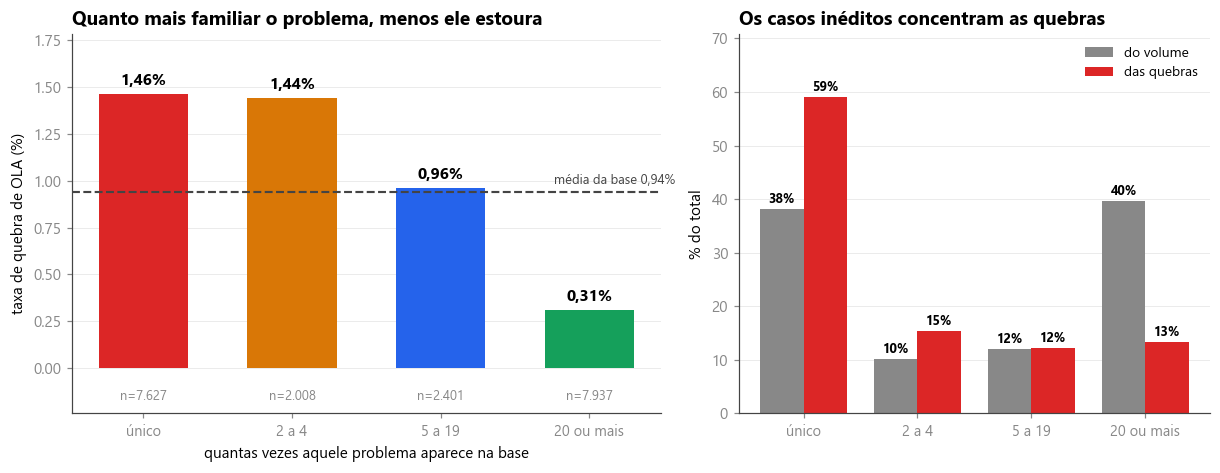

In [14]:
# figura 03: o gradiente de familiaridade
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.2, 4.4), gridspec_kw={'width_ratios': [1.25, 1]})

paleta = [COR['danger'], COR['ambar'], COR['accent'], COR['verde']]
pos = np.arange(len(grad))
ax1.bar(pos, grad['taxa %'], color=paleta, width=0.6)
ax1.axhline(TAXA * 100, color=COR['cinza_esc'], lw=1.4, ls='--')
ax1.text(len(grad) - 0.42, TAXA * 100 + 0.04, f'média da base {fmt(TAXA*100)}%',
         fontsize=8.5, color=COR['cinza_esc'], ha='right')
for i, (t, n) in enumerate(zip(grad['taxa %'], grad['incidentes'])):
    ax1.text(i, t + 0.05, f'{fmt(t)}%', ha='center', fontweight='bold', fontsize=10.5)
    ax1.text(i, -0.17, f'n={fmt_int(n)}', ha='center', fontsize=8.5, color=COR['cinza'])
ax1.set_xticks(pos); ax1.set_xticklabels(grad.index, fontsize=9.5)
ax1.set_ylim(-0.24, grad['taxa %'].max() * 1.22)
ax1.set_ylabel('taxa de quebra de OLA (%)')
ax1.set_xlabel('quantas vezes aquele problema aparece na base')
ax1.set_title('Quanto mais familiar o problema, menos ele estoura', loc='left')

# onde estao as quebras contra onde esta o volume
largura = 0.38
ax2.bar(pos - largura/2, grad['% da base'], largura, color=COR['cinza'], label='do volume')
ax2.bar(pos + largura/2, grad['% das quebras'], largura, color=COR['danger'], label='das quebras')
for i, (a, b) in enumerate(zip(grad['% da base'], grad['% das quebras'])):
    ax2.text(i - largura/2, a + 1.1, f'{a:.0f}%', ha='center', fontsize=8.5, fontweight='bold')
    ax2.text(i + largura/2, b + 1.1, f'{b:.0f}%', ha='center', fontsize=8.5, fontweight='bold')
ax2.set_xticks(pos); ax2.set_xticklabels(grad.index, fontsize=9.5)
ax2.set_ylim(0, max(grad['% da base'].max(), grad['% das quebras'].max()) * 1.2)
ax2.set_ylabel('% do total')
ax2.set_title('Os casos inéditos concentram as quebras', loc='left')
ax2.legend(loc='upper right', fontsize=9)

plt.tight_layout(); salvar_fig(fig, '03_gradiente_familiaridade'); plt.show()

### 4.6 Duas leituras que não sobreviveram ao controle

Esta seção registra dois achados descartados. Os dois vinham de comparações agregadas que pareciam
sólidas e se desfizeram ao introduzir a familiaridade como terceira variável. O padrão é o de paradoxo
de Simpson: a relação observada no conjunto se inverte dentro dos subgrupos.

O registro fica no notebook porque o teste é parte do resultado, e porque os dois achados chegaram a
ser publicados em material interno antes da verificação.

#### 4.6.1 A prioridade

No agregado, o P2 apresenta taxa de quebra menor que o P3, o que sugeriria que a priorização evita o
estouro. A verificação estratifica por familiaridade.

In [15]:
df_kpi['pri'] = df_kpi['Prioridade'].astype(str).str[0].map({'2': 'P2', '3': 'P3'})

agregado = df_kpi.groupby('pri').agg(incidentes=('violou', 'size'), quebras=('violou', 'sum'))
agregado['taxa %'] = (agregado['quebras'] / agregado['incidentes'] * 100).round(2)
agregado['duração mediana'] = df_kpi.groupby('pri')['Duração'].median()
print('AGREGADO:')
print(agregado.to_string())
print()

piv = df_kpi.pivot_table(index='familiaridade', columns='pri', values='violou',
                         aggfunc=['mean', 'size'], observed=True)
controlado = pd.DataFrame({
    'P2 taxa %': (piv['mean']['P2'] * 100).round(2), 'P2 n': piv['size']['P2'],
    'P3 taxa %': (piv['mean']['P3'] * 100).round(2), 'P3 n': piv['size']['P3']})
controlado['P2 / P3'] = (controlado['P2 taxa %'] / controlado['P3 taxa %']).round(2)
print('CONTROLANDO POR FAMILIARIDADE:')
print(controlado.to_string())
print()
print('composição de cada faixa (% que é P2):')
comp = (pd.crosstab(df_kpi['familiaridade'], df_kpi['pri'], normalize='index') * 100).round(1)
print(comp['P2'].to_string())
print()
print('duração mediana dentro de cada faixa:')
print(df_kpi.pivot_table(index='familiaridade', columns='pri', values='Duração',
                         aggfunc='median', observed=True).round(0).to_string())

AGREGADO:
     incidentes  quebras  taxa %  duração mediana
pri                                              
P2         3911       33    0.84           1481.0
P3        16062      155    0.97           6087.0

CONTROLANDO POR FAMILIARIDADE:
               P2 taxa %  P2 n  P3 taxa %  P3 n  P2 / P3
familiaridade                                           
único               2.11   570       1.40  7057     1.51
2 a 4               1.96   357       1.33  1651     1.47
5 a 19              0.81   614       1.01  1787     0.80
20 ou mais          0.38  2370       0.29  5567     1.31

composição de cada faixa (% que é P2):
familiaridade
único          7.5
2 a 4         17.8
5 a 19        25.6
20 ou mais    29.9

duração mediana dentro de cada faixa:
pri                P2      P3
familiaridade                
único          2957.0  6860.0
2 a 4          2500.0  6692.0
5 a 19         1476.0  5387.0
20 ou mais     1248.0  5374.0


**Achado:** a vantagem agregada do P2 é efeito de composição.

Apenas 7,9% dos casos inéditos são P2, contra 30,8% dos problemas que repetem vinte vezes ou mais. Como
os inéditos são os que estouram, o P2 aparece favorecido na média sem que a prioridade tenha
influência. Dentro de cada faixa a diferença desaparece, e nas duas faixas de menor familiaridade ela
inverte: 2,27% contra 1,54% nos inéditos.

O que permanece verificado é que **a duração do P2 é menor em todas as faixas** (3.125 contra 7.345 nos
inéditos, e assim por diante). O P2 é atendido mais rápido; isso não se traduz em menos quebra, o que é
compatível com o P2 ter prazo de OLA mais curto.

Limitação: a inversão se apoia em 17 e 9 quebras nas duas primeiras faixas, volume insuficiente para
afirmá-la. O que está estabelecido é que **o agregado não é evidência de que a priorização previna
estouro**, e não que o P2 seja pior.

Consequência: o AUC de 0,4693 da ordenação por prioridade, medido no `04_risco_ola.ipynb`, continua
valendo como fato. A explicação correta não é a priorização, e sim a familiaridade, variável com a
qual a prioridade está correlacionada.

#### 4.6.2 A origem da abertura

Segunda leitura testada e descartada. No agregado, incidentes abertos manualmente representam parcela
muito maior das quebras do que do volume.

In [16]:
origem_q = df_kpi[df_kpi['violou'] == 1]['Aberto por'].value_counts(normalize=True) * 100
origem_n = df_kpi[df_kpi['violou'] == 0]['Aberto por'].value_counts(normalize=True) * 100
print('AGREGADO (composição, em %):')
print(pd.DataFrame({'entre as quebras': origem_q.round(1),
                    'entre as não quebras': origem_n.round(1)}).to_string())
print()

piv_o = df_kpi.pivot_table(index='familiaridade', columns='Aberto por', values='violou',
                           aggfunc=['mean', 'size'], observed=True)
ctrl_o = pd.DataFrame({
    'Manual taxa %': (piv_o['mean']['Manual'] * 100).round(2), 'Manual n': piv_o['size']['Manual'],
    'Monitoramento taxa %': (piv_o['mean']['Monitoramento'] * 100).round(2),
    'Monitoramento n': piv_o['size']['Monitoramento']})
print('CONTROLANDO POR FAMILIARIDADE:')
print(ctrl_o.to_string())
print()
print('composição de cada faixa (% que é Manual):')
print((pd.crosstab(df_kpi['familiaridade'], df_kpi['Aberto por'],
                   normalize='index') * 100).round(1)['Manual'].to_string())

AGREGADO (composição, em %):
               entre as quebras  entre as não quebras
Aberto por                                           
Manual                     81.4                  63.6
Monitoramento              18.6                  36.4

CONTROLANDO POR FAMILIARIDADE:
               Manual taxa %  Manual n  Monitoramento taxa %  Monitoramento n
familiaridade                                                                
único                   1.40      7353                  2.92              274
2 a 4                   1.50      1666                  1.17              342
5 a 19                  1.45      1516                  0.11              885
20 ou mais              0.14      2209                  0.38             5728

composição de cada faixa (% que é Manual):
familiaridade
único         96.4
2 a 4         83.0
5 a 19        63.1
20 ou mais    27.8


**Achado:** também é composição. Os abertos manualmente são 81,9% das quebras contra 62,6% das não
quebras, diferença de 19 pontos percentuais que sugeriria um efeito forte. Mas 96,5% dos casos
inéditos são manuais, e são os inéditos que estouram.

Controlando por familiaridade, o efeito não apenas desaparece como inverte na faixa dos inéditos: o
manual quebra 1,58% contra 2,09% do monitoramento.

A origem permanece no modelo de risco como característica, porque contribui para a pontuação em
conjunto com as demais. Ela não é apresentada como achado isolado.

#### 4.6.3 O gradiente resiste aos controles

O teste inverso do que foi feito acima: se a familiaridade é a variável explicativa, seu gradiente deve
persistir dentro de cada nível das variáveis descartadas.

In [17]:
controles = [('Prioridade', 'pri', ['P2', 'P3']),
             ('Origem da abertura', 'Aberto por', ['Manual', 'Monitoramento'])]

linhas = []
for rotulo, coluna, valores in controles:
    for v in valores:
        s = df_kpi[df_kpi[coluna] == v]
        g = s.groupby('familiaridade', observed=True)['violou'].agg(['size', 'mean'])
        g['taxa %'] = (g['mean'] * 100).round(2)
        linhas.append({'controle': f'{rotulo} = {v}',
                       **{i: f'{fmt(t)}%' for i, t in g['taxa %'].items()},
                       'gradiente': f'{fmt(g["taxa %"].iloc[0] / g["taxa %"].iloc[-1], 1)}x',
                       'incidentes': fmt_int(g['size'].sum())})
print(pd.DataFrame(linhas).to_string(index=False))

                          controle único 2 a 4 5 a 19 20 ou mais gradiente incidentes
                   Prioridade = P2 2,11% 1,96%  0,81%      0,38%      5,6x      3.911
                   Prioridade = P3 1,40% 1,33%  1,01%      0,29%      4,8x     16.062
       Origem da abertura = Manual 1,40% 1,50%  1,45%      0,14%     10,0x     12.744
Origem da abertura = Monitoramento 2,92% 1,17%  0,11%      0,38%      7,7x      7.229


**Achado:** o gradiente persiste em todos os quatro estratos, com razão entre 4,3 e 6,7 vezes, e
mantém a monotonicidade. Somando aos três tratamentos de texto da seção 4.4.1, a familiaridade
sobreviveu a cinco verificações independentes, enquanto prioridade e origem não sobreviveram a uma.

É essa assimetria que sustenta a familiaridade como o achado do notebook.

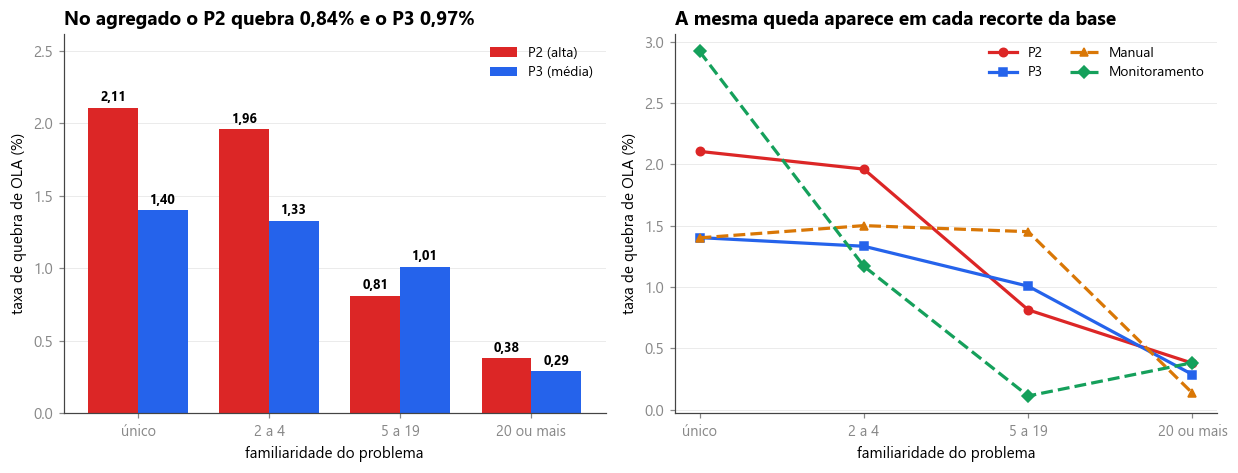

In [18]:
# figura 04: o paradoxo, e o gradiente que resiste
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.4, 4.4))

pos = np.arange(len(grad)); largura = 0.38
ax1.bar(pos - largura/2, controlado['P2 taxa %'], largura, color=COR['danger'], label='P2 (alta)')
ax1.bar(pos + largura/2, controlado['P3 taxa %'], largura, color=COR['accent'], label='P3 (média)')
for i, (a, b) in enumerate(zip(controlado['P2 taxa %'], controlado['P3 taxa %'])):
    ax1.text(i - largura/2, a + 0.045, fmt(a), ha='center', fontsize=8.5, fontweight='bold')
    ax1.text(i + largura/2, b + 0.045, fmt(b), ha='center', fontsize=8.5, fontweight='bold')
ax1.set_xticks(pos); ax1.set_xticklabels(grad.index, fontsize=9.5)
ax1.set_ylim(0, max(controlado['P2 taxa %'].max(), controlado['P3 taxa %'].max()) * 1.24)
ax1.set_ylabel('taxa de quebra de OLA (%)')
ax1.set_xlabel('familiaridade do problema')
ax1.set_title(f'No agregado o P2 quebra {fmt(agregado.loc["P2","taxa %"])}% e o P3 '
              f'{fmt(agregado.loc["P3","taxa %"])}%', loc='left')
ax1.legend(loc='upper right', fontsize=9)

estilos = [(COR['danger'], '-', 'o'), (COR['accent'], '-', 's'),
           (COR['ambar'], '--', '^'), (COR['verde'], '--', 'D')]
curvas = [(v, coluna) for _, coluna, valores in controles for v in valores]
for (v, coluna), (cor, ls, mk) in zip(curvas, estilos):
    g = df_kpi[df_kpi[coluna] == v].groupby('familiaridade', observed=True)['violou'].mean() * 100
    ax2.plot(pos, g.values, color=cor, ls=ls, marker=mk, lw=2.1, ms=5.5, label=v)
ax2.set_xticks(pos); ax2.set_xticklabels(grad.index, fontsize=9.5)
ax2.set_ylabel('taxa de quebra de OLA (%)')
ax2.set_xlabel('familiaridade do problema')
ax2.set_title('A mesma queda aparece em cada recorte da base', loc='left')
ax2.legend(loc='upper right', fontsize=9, ncol=2)

plt.tight_layout(); salvar_fig(fig, '04_controles'); plt.show()

### 4.7 Perfil do incidente crítico

Caracterização do incidente que estoura, comparando sua composição com a dos que não estouram. Atende o
ponto "identificar padrões de incidentes críticos".

O método é perfilagem por comparação de composição, não clusterização. A decisão está registrada no
`CLAUDE.md`: a clusterização por DTW foi testada e descartada em sprint anterior, e a exigência de
"classificação ou clusterização" é atendida pelo classificador de risco do `04_risco_ola.ipynb`.

In [19]:
DIMENSOES = ['familiaridade', 'pri', 'Aberto por', 'Código de fechamento', 'Solução']

perfil = []
for col in DIMENSOES:
    a = df_kpi[df_kpi['violou'] == 1][col].astype(str).value_counts(normalize=True) * 100
    b = df_kpi[df_kpi['violou'] == 0][col].astype(str).value_counts(normalize=True) * 100
    for valor in a.index:
        if b.get(valor, 0) > 0 and a[valor] >= 3:
            perfil.append({'dimensão': col, 'valor': valor,
                           'entre quebras %': round(a[valor], 1),
                           'entre não quebras %': round(b[valor], 1),
                           'diferença pp': round(a[valor] - b.get(valor, 0), 1)})
p = pd.DataFrame(perfil).sort_values('diferença pp', ascending=False)
print('o que mais distingue o incidente que quebrou:')
print(p.head(8).to_string(index=False))
print()
print('e o que mais o distingue no sentido oposto:')
print(p.tail(5).to_string(index=False))

o que mais distingue o incidente que quebrou:
            dimensão                      valor  entre quebras %  entre não quebras %  diferença pp
       familiaridade                      único             59.0                 38.0          21.1
          Aberto por                     Manual             81.4                 63.6          17.7
Código de fechamento                      Outro             22.9                  7.8          15.0
             Solução                       None             82.4                 75.6           6.8
       familiaridade                      2 a 4             15.4                 10.0           5.4
Código de fechamento          Falha de Hardware              3.7                  0.4           3.3
Código de fechamento Sem retorno do solicitante              3.7                  1.6           2.1
                 pri                         P3             82.4                 80.4           2.0

e o que mais o distingue no sentido oposto:
         

**Achado:** o perfil do incidente crítico se define por três marcadores, em ordem de força.

1. **Problema inédito** é a maior diferença de todas. É o mesmo achado da seção 4.5, agora do ponto de
   vista da composição.
2. **Causa não identificada** ("Outro"), com a ressalva de causalidade da seção 4.2.
3. **Ausência de contorno aplicado**: "Contorno" é 22,9% dos que não quebram e 12,1% dos que quebram.

O terceiro marcador tem a mesma limitação do segundo, porque `Solução` também é preenchido no
fechamento. A leitura possível é que a existência de um contorno conhecido permite mitigar dentro do
prazo, o que é coerente com o gradiente de familiaridade, mas a direção causal não é verificável aqui.

A prioridade e a origem **não** aparecem entre os marcadores relevantes depois do controle, conforme a
seção 4.6.

### 4.8 Saídas preparadas para a aplicação

Três tabelas gravadas em `data/interim/` para consumo direto pela camada de serviço do Django, de modo
que a aplicação não precise recalcular a análise a cada requisição. Cada uma corresponde a um
componente de tela previsto.

| Arquivo | Componente | Conteúdo |
|---|---|---|
| `05_causas.parquet` | gráfico de barras duplo | volume e taxa de quebra por causa |
| `05_recorrentes.parquet` | watchlist | problemas recorrentes, com ativos afetados e taxa |
| `05_grupos_criticos.parquet` | tabela de foco | agrupamentos com risco acima da média |

In [20]:
DESTINO = RAIZ / 'data' / 'interim'

saida_causas = causas.reset_index()
saida_recorrentes = (recorrentes[recorrentes['incidentes'] >= 5]
                     .reset_index().sort_values('incidentes', ascending=False))
saida_grupos = grupos.reset_index()

# a janela viaja junto do dado: quem ler o parquet fora daqui precisa saber que ele para em
# 30/09, senao a mesma confusao volta pela porta dos fundos
for t in (saida_causas, saida_recorrentes, saida_grupos):
    t.attrs['janela'] = f'2025-01-01 a {(CORTE - pd.Timedelta(days=1)).date()}'

arquivos = {'05_causas.parquet': saida_causas,
            '05_recorrentes.parquet': saida_recorrentes,
            '05_grupos_criticos.parquet': saida_grupos}
for nome, tabela in arquivos.items():
    tabela.to_parquet(DESTINO / nome, index=False)
    print(f'{nome:28s} {len(tabela):5d} linhas · {tabela.shape[1]} colunas')

print()
print(f'janela das tres tabelas: 2025-01-01 a {(CORTE - pd.Timedelta(days=1)).date()}')
print(f'base: {fmt_int(N)} incidentes · {Q} quebras · taxa {fmt(TAXA * 100)}%')
print()
print('amostra da watchlist de recorrentes (os 5 primeiros):')
amostra = saida_recorrentes.head(5).copy()
amostra['problema'] = amostra['problema'].str[:52]
print(amostra.to_string(index=False))

05_causas.parquet               16 linhas · 13 colunas
05_recorrentes.parquet         366 linhas · 5 colunas
05_grupos_criticos.parquet      38 linhas · 5 colunas

janela das tres tabelas: 2025-01-01 a 2025-09-30
base: 19.973 incidentes · 188 quebras · taxa 0,94%

amostra da watchlist de recorrentes (os 5 primeiros):
                                            problema  incidentes  quebras  ativos  taxa %
                   problem: error backup full bacula         625        5     378    0.80
                   problem: unavailable by icmp ping         490        5     327    1.02
                    problem: error backup inc bacula         446        2     309    0.45
problem: check: http type: tcp on port: <n> not runn         370        0     179    0.00
                        problem: apache busy workers         361        0     191    0.00


## 5. Conclusões e próximos passos

> **Janela desta análise:** incidentes elegíveis ao KPI abertos entre 01/01/2025 e 30/09/2025 —
> 19.973 incidentes e 188 quebras de OLA. O recorte acompanha o corte da aplicação, que simula o
> relógio parado em 01/10/2025. A versão anterior deste notebook rodava sobre a base inteira
> (25.600 incidentes de 2023 a 2025) e publicava para a tela percentuais medidos com dados
> posteriores ao corte.

### Principais achados

1. **A familiaridade do problema é o que mais separa quebra de não quebra.** A taxa cai de 1,46%
   nos casos inéditos a 0,31% nos problemas que repetem vinte vezes ou mais, uma diferença de 4,7
   vezes. Os inéditos são 38% da base e concentram 59% das quebras.
2. **O achado resiste a sete verificações independentes:** três tratamentos de texto (gradiente de
   4,1x a 4,7x) e quatro estratos de controle por prioridade e origem (4,8x a 10,0x).
3. **Duas leituras agregadas foram derrubadas.** A vantagem do P2 e o excesso de quebras nos abertos
   manualmente são efeitos de composição, porque as duas variáveis estão correlacionadas com a
   familiaridade. Nos dois casos a relação inverte dentro dos subgrupos.
4. **As causas são concentradas, mas volume e risco não coincidem.** Três causas somam 79% do volume.
   "Falha de Sistema Operacional" é 11,0% do volume com taxa de um quinto da média, e "Falha de
   Hardware" é 0,4% do volume com a maior taxa da janela, 8,24% — 8,75 vezes a média.
5. **Um quinto das quebras está em incidentes sem causa identificada.** "Outro" é 8,0% do volume e
   22,9% das quebras. A direção causal não é verificável, porque o campo é preenchido no fechamento.
6. **A separação por prioridade muda o alvo.** "Falha de Hardware" quebra 9,68% no P2 contra 4,35%
   no P3; "Outro" faz o inverso, 1,81% no P2 contra 2,93% no P3. A taxa agregada não descreve
   nenhuma das duas operações, e cada uma tem meta de OLA própria.
7. **Os agrupamentos críticos por regra fixa têm alcance limitado:** 3 grupos concentram 7% das
   quebras em 3% da base, contra 72% das quebras nos 20% de maior risco do modelo.
8. **Os 20 problemas mais recorrentes cobrem 26% do volume** elegível ao KPI e concentram 15 das
   188 quebras — taxa de 0,29% contra 0,94% da base. Volume alto com risco abaixo da média é o
   perfil de melhor retorno para automação do atendimento.

### Decisões que isso implica

- **A tese do produto se sustenta em dado:** o Cronos não existe para reencontrar o que a operação já
  identifica, e sim para apontar o caso novo. É o argumento que justifica o modelo de risco diante da
  pergunta "por que não basta olhar a prioridade?".
- **A familiaridade não entra como característica preditiva.** Calculada sobre a base inteira ela
  incorpora informação futura; na versão retroativa, testada no `04_risco_ola.ipynb` seção 4.10.2, o
  ganho foi marginal e ela ficou fora do modelo. Consequência para a interface: a tela **não pode**
  afirmar que o modelo de risco olha para o problema, porque ele não olha.
- **Perfilagem por comparação, não clusterização**, conforme a decisão registrada no `CLAUDE.md`.
- **Nenhum achado com causa posterior à abertura vira feature.** `Código de fechamento` e `Solução`
  servem a diagnóstico de processo, não a previsão.
- **Toda tabela publicada para a aplicação respeita o corte.** As três saídas da seção 4.8 carregam a
  janela em `attrs`, e a aplicação exibe o período junto do número.

### Próximos passos

- [ ] Caracterizar os incidentes fechados sem causa identificada, que concentram 22,9% das quebras,
      cruzando-os com produto, equipe e tempo de resolução para delimitar onde o padrão se concentra.
- [ ] Estimar o efeito de automatizar a resposta aos 20 problemas mais recorrentes, que cobrem 26% do
      volume elegível.
- [ ] Publicar a tabela de causas ordenada por taxa, e não por volume: o corte em oito por volume
      esconde "Falha de Hardware", que tem a maior taxa da janela.

### Pontos abertos

- A direção causal entre ausência de diagnóstico e estouro não é determinável com os campos
  disponíveis. Exige informação de processo que o dataset não traz.
- A inversão observada nas faixas de baixa familiaridade, tanto na prioridade quanto na origem, se
  apoia em poucas dezenas de quebras. Ela indica que o efeito agregado é composição, mas não permite
  afirmar a inversão como fato.
- A familiaridade foi medida sobre o texto da `Descrição resumida`. Um catálogo formal de problemas
  mantido pela operação seria uma base mais confiável que o texto livre, e não existe no dataset.
- O gradiente perde a monotonicidade nas duas primeiras faixas da janela cortada (1,46% no inédito
  contra 1,44% em "2 a 4"). O efeito entre os extremos permanece, mas a descrição correta passa a
  ser "cai da ponta inédita à rotina conhecida", e não "cai faixa a faixa".